In [1]:
# ==============================
# 1. IMPORTAR LIBRERIAS
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuracion para visualizar mejor los dataframes
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

In [2]:
# ==============================
# 2. DEFINIR RUTAS DE ARCHIVOS
# ==============================

ruta_bank = "../datos/datos_brutos/bank-additional.csv"
ruta_customer = "../datos/datos_brutos/customer-details.xlsx"

In [3]:
# ==============================
# 3. CARGAR DATASET PRINCIPAL CSV
# ==============================

df_bank = pd.read_csv(ruta_bank,  sep=",")

# Primer vistazo
df_bank.head()

,Unnamed: 0,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_
0,0,NaN,housemaid,MARRIED,basic.4y,0.00,0.00,0.00,telephone,261,1,999,0,NONEXISTENT,1.10,"93,994","-36,4","4,857",5191,no,2-agosto-2019,41.49,-71.23,089b39d8-e4d0-461b-87d4-814d71e0e079
1,1,57.00,services,MARRIED,high.school,NaN,0.00,0.00,telephone,149,1,999,0,NONEXISTENT,1.10,"93,994","-36,4",NaN,5191,no,14-septiembre-2016,34.60,-83.92,e9d37224-cb6f-4942-98d7-46672963d097
2,2,37.00,services,MARRIED,high.school,0.00,1.00,0.00,telephone,226,1,999,0,NONEXISTENT,1.10,"93,994","-36,4","4,857",5191,no,15-febrero-2019,34.94,-94.85,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,3,40.00,admin.,MARRIED,basic.6y,0.00,0.00,0.00,telephone,151,1,999,0,NONEXISTENT,1.10,"93,994","-36,4",NaN,5191,no,29-noviembre-2015,49.04,-70.31,9991fafb-4447-451a-8be2-b0df6098d13e
4,4,56.00,services,MARRIED,high.school,0.00,0.00,1.00,telephone,307,1,999,0,NONEXISTENT,1.10,"93,994","-36,4",NaN,5191,no,29-enero-2017,38.03,-104.46,eca60b76-70b6-4077-80ba-bc52e8ebb0eb


In [4]:
df_bank.columns.tolist()

['Unnamed: 0',
 'age',
 'job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed',
 'y',
 'date',
 'latitude',
 'longitude',
 'id_']

In [5]:
df_bank.drop(columns=["Unnamed: 0"], inplace=True)

In [6]:
df_bank.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'duration', 'campaign', 'pdays', 'previous', 'poutcome',
       'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m',
       'nr.employed', 'y', 'date', 'latitude', 'longitude', 'id_'],
      dtype='object')

In [7]:
# ==============================
# 4. CARGAR EXCEL CON VARIAS HOJAS
# ==============================

excel_customer = pd.read_excel(ruta_customer, sheet_name=None)

# Ver nombres de las hojas
excel_customer.keys()

dict_keys(['2012', '2013', '2014'])

In [8]:
# ==============================
# 5. UNIR LAS HOJAS DEL EXCEL
# ==============================

df_customer = pd.concat(excel_customer.values(), ignore_index=True)

df_customer.head()

,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
0,0,161770,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079
1,1,85477,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097
2,2,147233,1,1,2012-02-02,5,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,3,121393,1,2,2012-12-21,29,9991fafb-4447-451a-8be2-b0df6098d13e
4,4,63164,1,2,2012-06-20,20,eca60b76-70b6-4077-80ba-bc52e8ebb0eb


In [9]:
df_customer.drop(columns=["Unnamed: 0"], inplace=True)

In [10]:
df_customer.columns

Index(['Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'NumWebVisitsMonth',
       'ID'],
      dtype='object')

In [11]:
# ==============================
# 6. REVISION GENERAL DE LOS DATASETS
# ==============================

print("Shape df_bank:", df_bank.shape)
print("Shape df_customer:", df_customer.shape)

Shape df_bank: (43000, 23)
Shape df_customer: (43170, 6)


In [12]:
# Informacion general del dataset bancario
df_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             37880 non-null  float64
 1   job             42655 non-null  object 
 2   marital         42915 non-null  object 
 3   education       41193 non-null  object 
 4   default         34019 non-null  float64
 5   housing         41974 non-null  float64
 6   loan            41974 non-null  float64
 7   contact         43000 non-null  object 
 8   duration        43000 non-null  int64  
 9   campaign        43000 non-null  int64  
 10  pdays           43000 non-null  int64  
 11  previous        43000 non-null  int64  
 12  poutcome        43000 non-null  object 
 13  emp.var.rate    43000 non-null  float64
 14  cons.price.idx  42529 non-null  object 
 15  cons.conf.idx   43000 non-null  object 
 16  euribor3m       33744 non-null  object 
 17  nr.employed     43000 non-null 

In [13]:
# Informacion general del dataset clientes
df_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43170 entries, 0 to 43169
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Income             43170 non-null  int64         
 1   Kidhome            43170 non-null  int64         
 2   Teenhome           43170 non-null  int64         
 3   Dt_Customer        43170 non-null  datetime64[ns]
 4   NumWebVisitsMonth  43170 non-null  int64         
 5   ID                 43170 non-null  object        
dtypes: datetime64[ns](1), int64(4), object(1)
memory usage: 2.0+ MB


In [14]:
# ==============================
# 7. ESTADISTICOS DESCRIPTIVOS
# ==============================

df_bank.describe()

,age,default,housing,loan,duration,campaign,pdays,previous,emp.var.rate,latitude,longitude
count,37880.00,34019.00,41974.00,41974.00,43000.00,43000.00,43000.00,43000.00,43000.00,43000.00,43000.00
mean,39.98,0.00,0.54,0.16,257.74,2.57,962.33,0.17,0.08,36.86,-95.94
std,10.44,0.01,0.50,0.36,258.67,2.77,187.26,0.50,1.57,7.23,16.75
min,17.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,-3.40,24.40,-125.00
25%,32.00,0.00,0.00,0.00,102.00,1.00,999.00,0.00,-1.80,30.61,-110.49
50%,38.00,0.00,1.00,0.00,179.00,2.00,999.00,0.00,1.10,36.76,-95.90
75%,47.00,0.00,1.00,0.00,319.00,3.00,999.00,0.00,1.40,43.11,-81.43
max,98.00,1.00,1.00,1.00,4918.00,56.00,999.00,7.00,1.40,49.38,-66.94


In [15]:
# ==============================
# 7. ESTADISTICOS DESCRIPTIVOS
# ==============================
 
df_customer.describe()

,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth
count,43170.00,43170.00,43170.00,43170,43170.00
mean,93227.39,1.00,1.00,2013-05-11 22:09:47.407922176,16.59
min,5841.00,0.00,0.00,2012-01-01 00:00:00,1.00
25%,49608.00,0.00,0.00,2012-07-16 00:00:00,9.00
50%,93009.50,1.00,1.00,2013-03-01 00:00:00,17.00
75%,136740.50,2.00,2.00,2014-03-28 00:00:00,25.00
max,180802.00,2.00,2.00,2014-12-31 00:00:00,32.00
std,50498.18,0.82,0.82,NaN,9.24


In [16]:
# Estadisticos para variables categoricas
df_bank.describe(include="object")

,job,marital,education,contact,poutcome,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,id_
count,42655,42915,41193,43000,43000,42529,43000,33744,43000,43000,42752,43000
unique,11,3,7,2,3,26,26,309,11,2,1825,43000
top,admin.,MARRIED,university.degree,cellular,NONEXISTENT,"93,994","-36,4","4,857","5228,1",no,28-febrero-2018,993bbbd6-4dbc-4a40-a408-f91f8462bee6
freq,10873,25999,12722,27396,37103,7938,8020,2287,16980,38156,95,1


In [17]:
# Estadisticos para variables categoricas
df_customer.describe(include="object")

,ID
count,43170
unique,43170
top,9727bc06-c11a-461a-a5bb-3d210467cc2a
freq,1


In [18]:
# ==============================
# 8. VALORES NULOS
# ==============================

nulos_bank = df_bank.isnull().sum().sort_values(ascending=False)
nulos_bank

euribor3m         9256
default           8981
age               5120
education         1807
housing           1026
loan              1026
cons.price.idx     471
job                345
date               248
marital             85
contact              0
pdays                0
previous             0
campaign             0
duration             0
emp.var.rate         0
poutcome             0
nr.employed          0
cons.conf.idx        0
y                    0
latitude             0
longitude            0
id_                  0
dtype: int64

In [19]:
# ==============================
# 8. VALORES NULOS
# ==============================
 
nulos_customer = df_customer.isnull().sum().sort_values(ascending=False)
nulos_customer

Income               0
Kidhome              0
Teenhome             0
Dt_Customer          0
NumWebVisitsMonth    0
ID                   0
dtype: int64

In [20]:
# Porcentaje de nulos en df_bank
porcentaje_nulos_bank = (df_bank.isnull().sum() / len(df_bank) * 100).sort_values(ascending=False)
porcentaje_nulos_bank

euribor3m        21.53
default          20.89
age              11.91
education         4.20
housing           2.39
loan              2.39
cons.price.idx    1.10
job               0.80
date              0.58
marital           0.20
contact           0.00
pdays             0.00
previous          0.00
campaign          0.00
duration          0.00
emp.var.rate      0.00
poutcome          0.00
nr.employed       0.00
cons.conf.idx     0.00
y                 0.00
latitude          0.00
longitude         0.00
id_               0.00
dtype: float64

In [21]:
# Porcentaje de nulos en df_customer
porcentaje_nulos_customer = (df_customer.isnull().sum() / len(df_customer) * 100).sort_values(ascending=False)
porcentaje_nulos_customer

Income              0.00
Kidhome             0.00
Teenhome            0.00
Dt_Customer         0.00
NumWebVisitsMonth   0.00
ID                  0.00
dtype: float64

In [22]:
# ==============================
# 9. DUPLICADOS
# ==============================

print("Duplicados df_bank:", df_bank.duplicated().sum())
print("Duplicados df_customer:", df_customer.duplicated().sum())

Duplicados df_bank: 0
Duplicados df_customer: 0


In [23]:
# ==============================
# 10. VALORES UNICOS POR COLUMNA
# ==============================

for columna in df_bank.columns:
    print(f"{columna}: {df_bank[columna].nunique()} valores unicos")

age: 78 valores unicos
job: 11 valores unicos
marital: 3 valores unicos
education: 7 valores unicos
default: 2 valores unicos
housing: 2 valores unicos
loan: 2 valores unicos
contact: 2 valores unicos
duration: 1540 valores unicos
campaign: 42 valores unicos
pdays: 27 valores unicos
previous: 8 valores unicos
poutcome: 3 valores unicos
emp.var.rate: 10 valores unicos
cons.price.idx: 26 valores unicos
cons.conf.idx: 26 valores unicos
euribor3m: 309 valores unicos
nr.employed: 11 valores unicos
y: 2 valores unicos
date: 1825 valores unicos
latitude: 20491 valores unicos
longitude: 30448 valores unicos
id_: 43000 valores unicos


In [24]:
# ==============================
# 10. VALORES UNICOS POR COLUMNA
# ==============================
  
for columna in df_customer.columns:
    print(f"{columna}: {df_customer[columna].nunique()} valores unicos")

Income: 38310 valores unicos
Kidhome: 3 valores unicos
Teenhome: 3 valores unicos
Dt_Customer: 1096 valores unicos
NumWebVisitsMonth: 32 valores unicos
ID: 43170 valores unicos


In [25]:
# ==============================
# 11. REVISION DE VARIABLES CATEGORICAS
# ==============================

columnas_categoricas_bank = df_bank.select_dtypes(include="object").columns

for columna in columnas_categoricas_bank:
    print(f"\nColumna: {columna}")
    print(df_bank[columna].value_counts())


Columna: job
job
admin.           10873
blue-collar       9654
technician        7026
services          4162
management        3050
retired           1790
entrepreneur      1522
self-employed     1489
housemaid         1123
unemployed        1063
student            903
Name: count, dtype: int64

Columna: marital
marital
MARRIED     25999
SINGLE      12105
DIVORCED     4811
Name: count, dtype: int64

Columna: education
education
university.degree      12722
high.school             9925
basic.9y                6309
professional.course     5477
basic.4y                4356
basic.6y                2386
illiterate                18
Name: count, dtype: int64

Columna: contact
contact
cellular     27396
telephone    15604
Name: count, dtype: int64

Columna: poutcome
poutcome
NONEXISTENT    37103
FAILURE         4461
SUCCESS         1436
Name: count, dtype: int64

Columna: cons.price.idx
cons.price.idx
93,994    7938
93,918    6937
92,893    5985
93,444    5349
94,465    4522
93,2      3731
9

In [26]:
# ==============================
# 11. REVISION DE VARIABLES CATEGORICAS
# ==============================
 
columnas_categoricas_customer = df_customer.select_dtypes(include="object").columns

for columna in columnas_categoricas_customer:
    print(f"\nColumna: {columna}")
    print(df_customer[columna].value_counts())


Columna: ID
ID
9727bc06-c11a-461a-a5bb-3d210467cc2a    1
089b39d8-e4d0-461b-87d4-814d71e0e079    1
5006b75e-18bb-46e9-ae1a-89f7eb79cc8a    1
e554d2ad-6c83-4603-93d4-fc596b807eff    1
3959015a-9713-4877-9a43-740e34c29eaf    1
                                       ..
5e3483e5-236d-437d-8351-541f9d09b9dd    1
d63ede72-0b6d-45b1-8872-385ac6897f65    1
eca60b76-70b6-4077-80ba-bc52e8ebb0eb    1
9991fafb-4447-451a-8be2-b0df6098d13e    1
3f9f49b5-e410-4948-bf6e-f9244f04918b    1
Name: count, Length: 43170, dtype: int64


In [27]:
# ==============================
# 12. REVISION DE VARIABLE OBJETIVO
# ==============================

df_bank["y"].value_counts()

y
no     38156
yes     4844
Name: count, dtype: int64

In [28]:
# ==============================
# 12. REVISION DE VARIABLE OBJETIVO
# ==============================
 
df_bank["y"].value_counts(normalize=True) * 100

y
no    88.73
yes   11.27
Name: proportion, dtype: float64

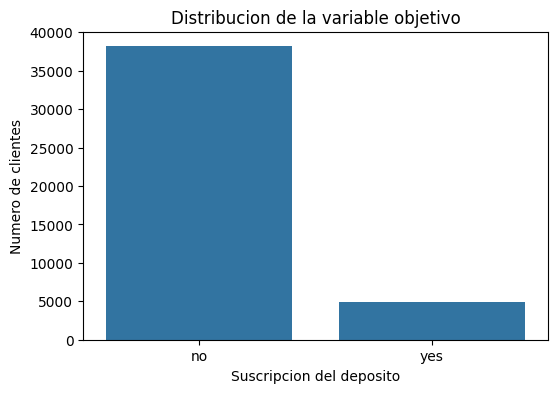

In [29]:
# Grafico de la variable objetivo
plt.figure(figsize=(6, 4))
sns.countplot(data=df_bank, x="y")
plt.title("Distribucion de la variable objetivo")
plt.xlabel("Suscripcion del deposito")
plt.ylabel("Numero de clientes")
plt.show()

In [31]:
# ==============================
# 13. PRIMERAS CONCLUSIONES DE LA EXPLORACION
# ==============================

print("========== RESUMEN INICIAL DEL PROYECTO ==========\n")

# INFORMACION GENERAL
print("INFORMACION GENERAL")
print(f"El dataset bancario tiene {df_bank.shape[0]} filas y {df_bank.shape[1]} columnas.")
print(f"El dataset de clientes tiene {df_customer.shape[0]} filas y {df_customer.shape[1]} columnas.\n")

# DUPLICADOS
print("DUPLICADOS")
print(f"Duplicados en df_bank: {df_bank.duplicated().sum()}")
print(f"Duplicados en df_customer: {df_customer.duplicated().sum()}\n")

# NULOS
print("VALORES NULOS")

print("\nNulos en df_bank:")
print(df_bank.isnull().sum())

print("\nNulos en df_customer:")
print(df_customer.isnull().sum())

# PORCENTAJE DE NULOS
print("\nPORCENTAJE DE NULOS")

print("\nPorcentaje de nulos en df_bank:")
print((df_bank.isnull().sum() / len(df_bank) * 100).round(2))

print("\nPorcentaje de nulos en df_customer:")
print((df_customer.isnull().sum() / len(df_customer) * 100).round(2))

# VARIABLE OBJETIVO
print("\nVARIABLE OBJETIVO: SUSCRIPCION DEL DEPOSITO")

print("\nConteo de clientes:")
print(df_bank["y"].value_counts())

print("\nPorcentaje de clientes:")
print((df_bank["y"].value_counts(normalize=True) * 100).round(2))

# INTERPRETACION BASICA
clientes_si = df_bank["y"].value_counts().get("yes", 0)
clientes_no = df_bank["y"].value_counts().get("no", 0)

print("\nINTERPRETACION INICIAL")
print(f"Clientes que SI se suscribieron: {clientes_si}")
print(f"Clientes que NO se suscribieron: {clientes_no}")

if clientes_no > clientes_si:
    print("La mayoria de clientes no contrataron el deposito.")
else:
    print("La mayoria de clientes contrataron el deposito.")

========== RESUMEN INICIAL DEL PROYECTO ==========

INFORMACION GENERAL
El dataset bancario tiene 43000 filas y 23 columnas.
El dataset de clientes tiene 43170 filas y 6 columnas.

DUPLICADOS
Duplicados en df_bank: 0
Duplicados en df_customer: 0

VALORES NULOS

Nulos en df_bank:
age               5120
job                345
marital             85
education         1807
default           8981
housing           1026
loan              1026
contact              0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx     471
cons.conf.idx        0
euribor3m         9256
nr.employed          0
y                    0
date               248
latitude             0
longitude            0
id_                  0
dtype: int64

Nulos en df_customer:
Income               0
Kidhome              0
Teenhome             0
Dt_Customer          0
NumWebVisitsMonth    0
ID                   0
dtype: int64

POR